# Per-area encoder: cosine similarity and 2-AFC

Compares test-set SigLIP cosine similarity and 2-AFC identification accuracy for encoders trained on each individual brain area (TE0, TE2, TE3, PRH, PHC) and the compound regions IT (TE0+TE2+TE3) and MT (PHC+PRH).

In [6]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
from config_const import CHECKPOINT_DIR


In [7]:
AREAS = ['TE0', 'TE2', 'TE3', 'IT', 'PRH', 'PHC', 'MT']
AREA_COLORS = {
    'TE0': '#4e79a7', 'TE2': '#f28e2b', 'TE3': '#e15759',
    'IT':  '#76b7b2',
    'PRH': '#59a14f', 'PHC': '#b07aa1',
    'MT':  '#ff9da7',
}

NCE_WEIGHT = 0.5  # select runs trained with this nce-weight


def load_area_ckpt(area: str, nce_weight: float = NCE_WEIGHT) -> dict | None:
    base = CHECKPOINT_DIR / 'multihead' / f'hvm_{area}'
    if not base.exists():
        return None
    tag = f'_nw{nce_weight}_'
    candidates = [d / 'best.pt' for d in base.iterdir()
                  if tag in d.name and (d / 'best.pt').exists()]
    if not candidates:
        return None
    ckpt = torch.load(candidates[0], weights_only=False, map_location='cpu')
    return {
        'area':      area,
        'val_cos':   ckpt['metrics']['val_cos_siglip'],
        'val_2afc':  ckpt['metrics']['val_2afc_siglip'],
        'test_cos':  ckpt['test_metrics']['test_cos_siglip'],
        'test_2afc': ckpt['test_metrics']['test_2afc_siglip'],
        'test_top1': ckpt['test_metrics']['test_top1_siglip'],
        'test_top5': ckpt['test_metrics']['test_top5_siglip'],
    }

results = {a: r for a in AREAS if (r := load_area_ckpt(a)) is not None}
for a, r in results.items():
    print(f"{a:4s}  val_cos={r['val_cos']:.3f}  val_2afc={r['val_2afc']:.3f}  "
          f"test_cos={r['test_cos']:.3f}  test_2afc={r['test_2afc']:.3f}  "
          f"top1={r['test_top1']:.3f}  top5={r['test_top5']:.3f}")


TE0   val_cos=0.419  val_2afc=0.732  test_cos=0.422  test_2afc=0.762  top1=0.033  top5=0.256
TE2   val_cos=0.538  val_2afc=0.723  test_cos=0.526  test_2afc=0.679  top1=0.033  top5=0.200
TE3   val_cos=0.516  val_2afc=0.775  test_cos=0.520  test_2afc=0.806  top1=0.089  top5=0.267
IT    val_cos=0.413  val_2afc=0.828  test_cos=0.408  test_2afc=0.821  top1=0.100  top5=0.233
PRH   val_cos=0.734  val_2afc=0.508  test_cos=0.727  test_2afc=0.483  top1=0.000  top5=0.044
PHC   val_cos=0.559  val_2afc=0.714  test_cos=0.555  test_2afc=0.718  top1=0.067  top5=0.200
MT    val_cos=0.555  val_2afc=0.715  test_cos=0.543  test_2afc=0.713  top1=0.044  top5=0.211


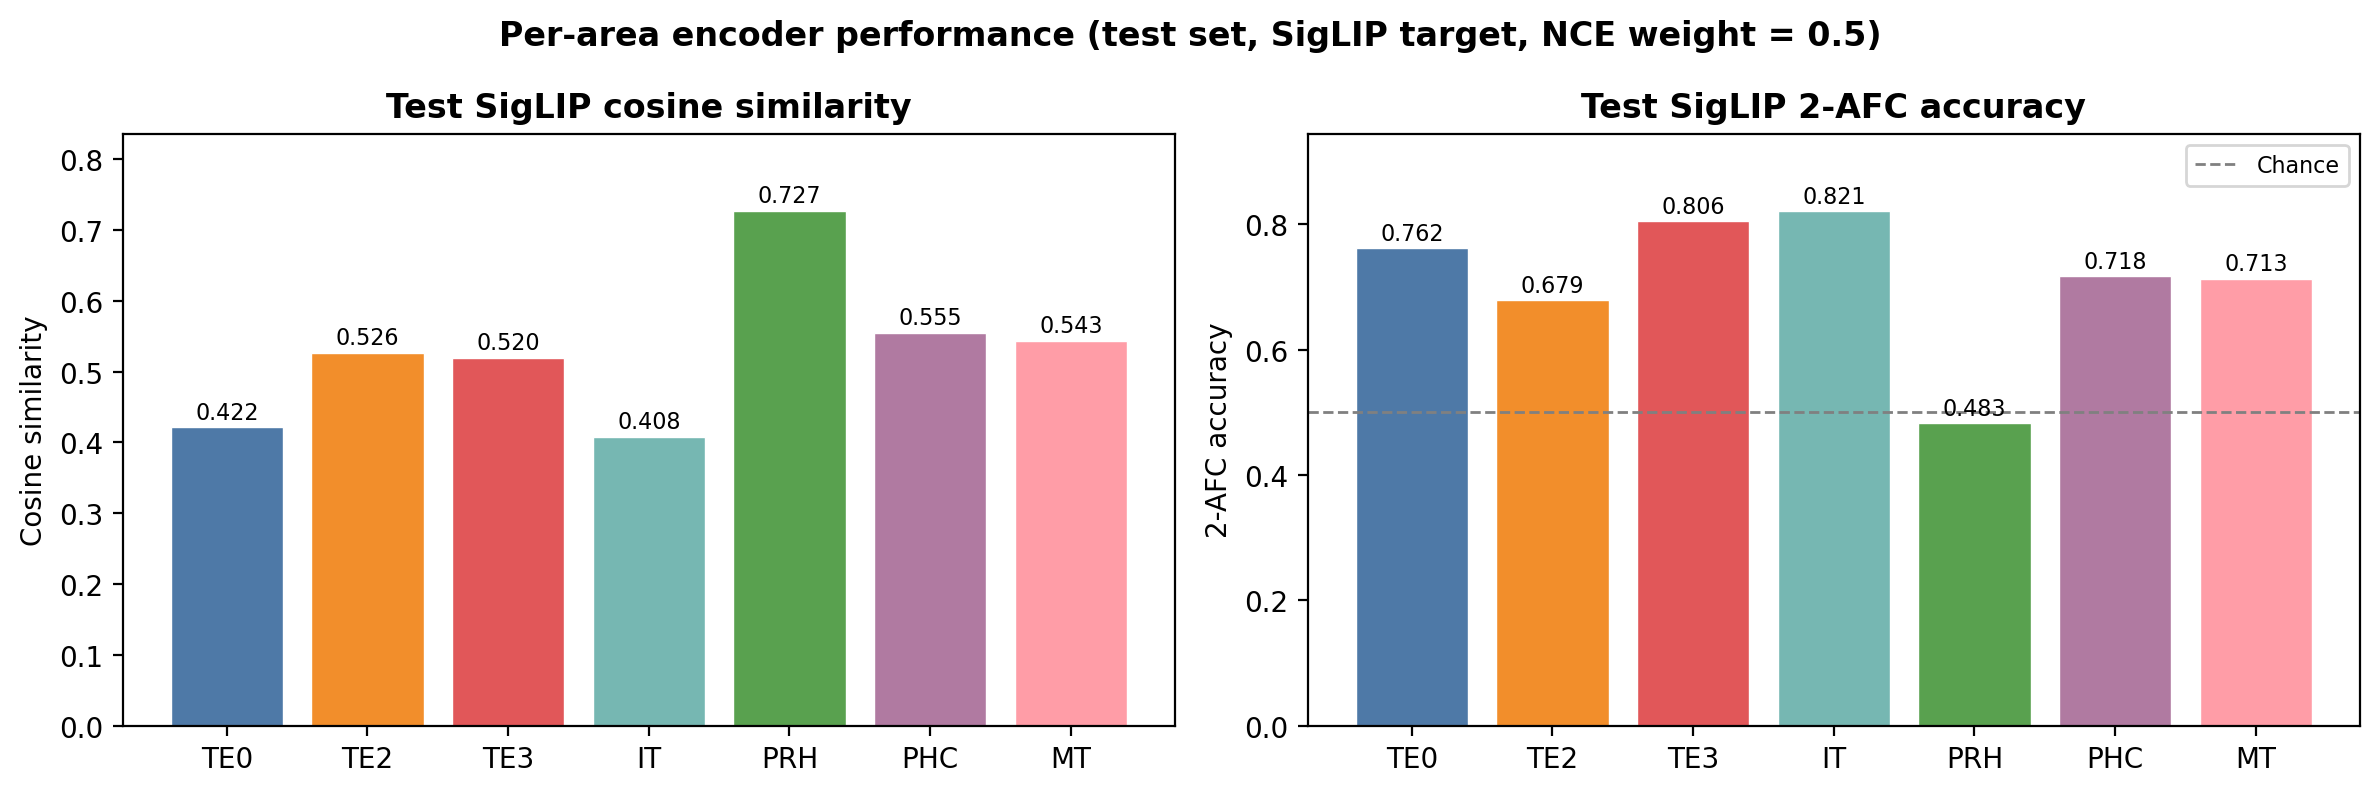

In [11]:
areas_present = [a for a in AREAS if a in results]
x = np.arange(len(areas_present))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = [AREA_COLORS[a] for a in areas_present]

for ax, key, ylabel, title, chance in [
    (axes[0], 'test_cos',  'Cosine similarity', 'Test SigLIP cosine similarity', None),
    (axes[1], 'test_2afc', '2-AFC accuracy',    'Test SigLIP 2-AFC accuracy',    0.5),
]:
    vals = [results[a][key] for a in areas_present]
    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
    if chance is not None:
        ax.axhline(chance, color='grey', ls='--', lw=1, label='Chance')
        ax.legend(fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(areas_present, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, min(1.05, max(vals) * 1.15))

fig.suptitle('Per-area encoder performance (test set, SigLIP target, NCE weight = 0.5)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()


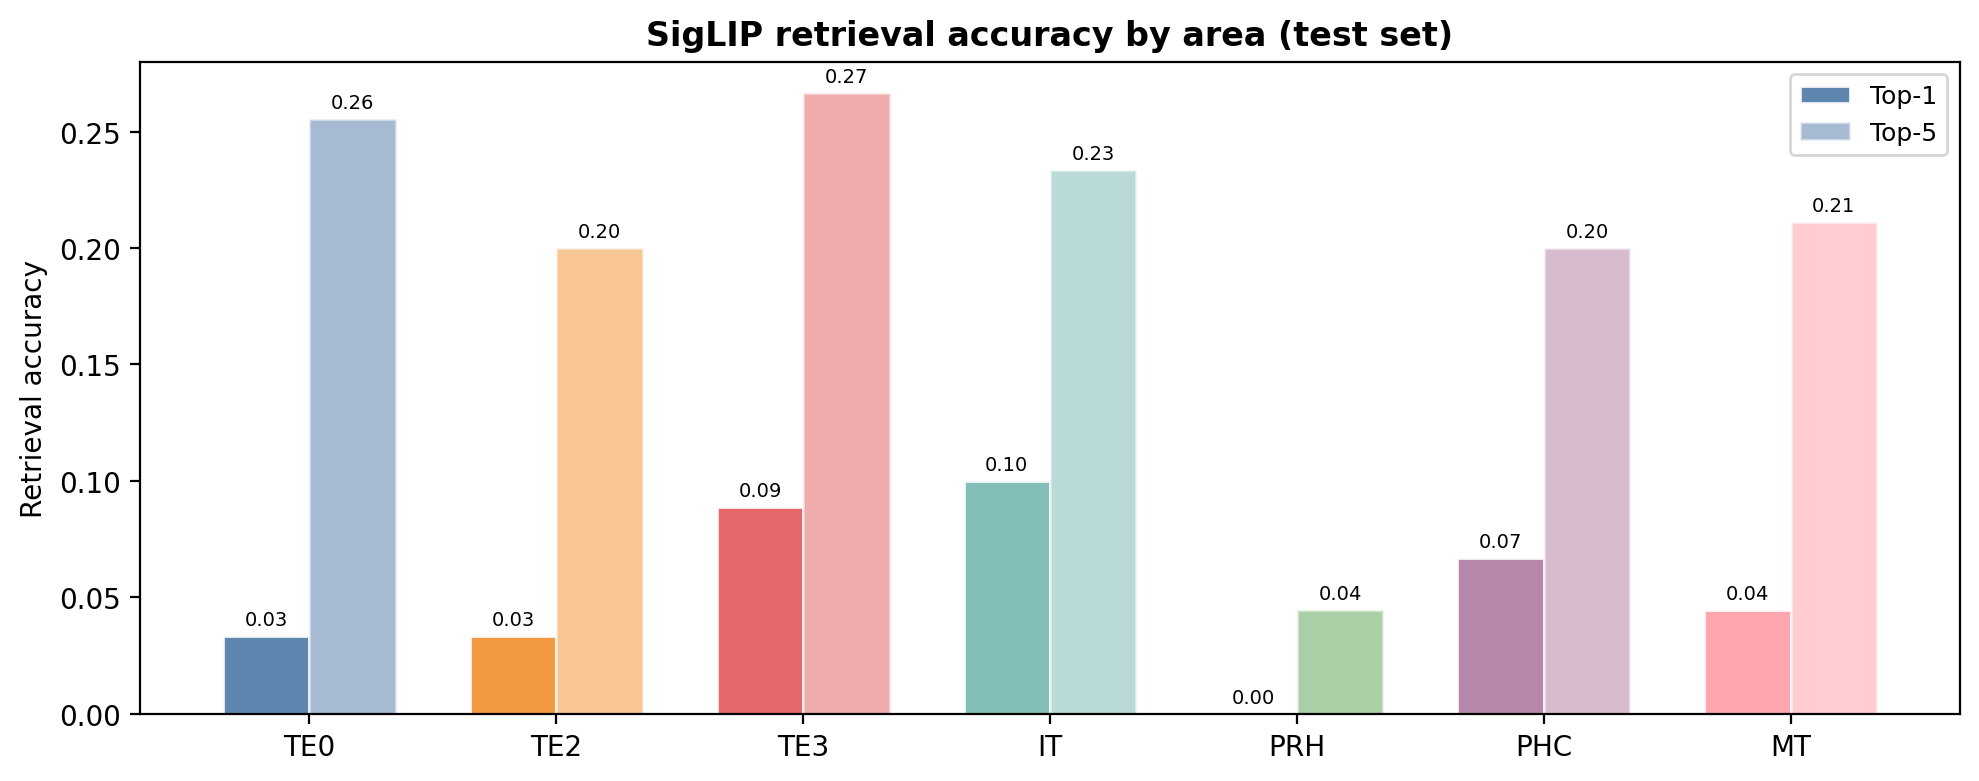

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
w = 0.35
x = np.arange(len(areas_present))

top1 = [results[a]['test_top1'] for a in areas_present]
top5 = [results[a]['test_top5'] for a in areas_present]

b1 = ax.bar(x - w/2, top1, w, color=colors, edgecolor='white', label='Top-1', alpha=0.9)
b5 = ax.bar(x + w/2, top5, w, color=colors, edgecolor='white', label='Top-5', alpha=0.5)

for bars, vals in [(b1, top1), (b5, top5)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003, f'{v:.2f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(areas_present, fontsize=10)
ax.set_ylabel('Retrieval accuracy')
ax.set_title('SigLIP retrieval accuracy by area (test set)', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


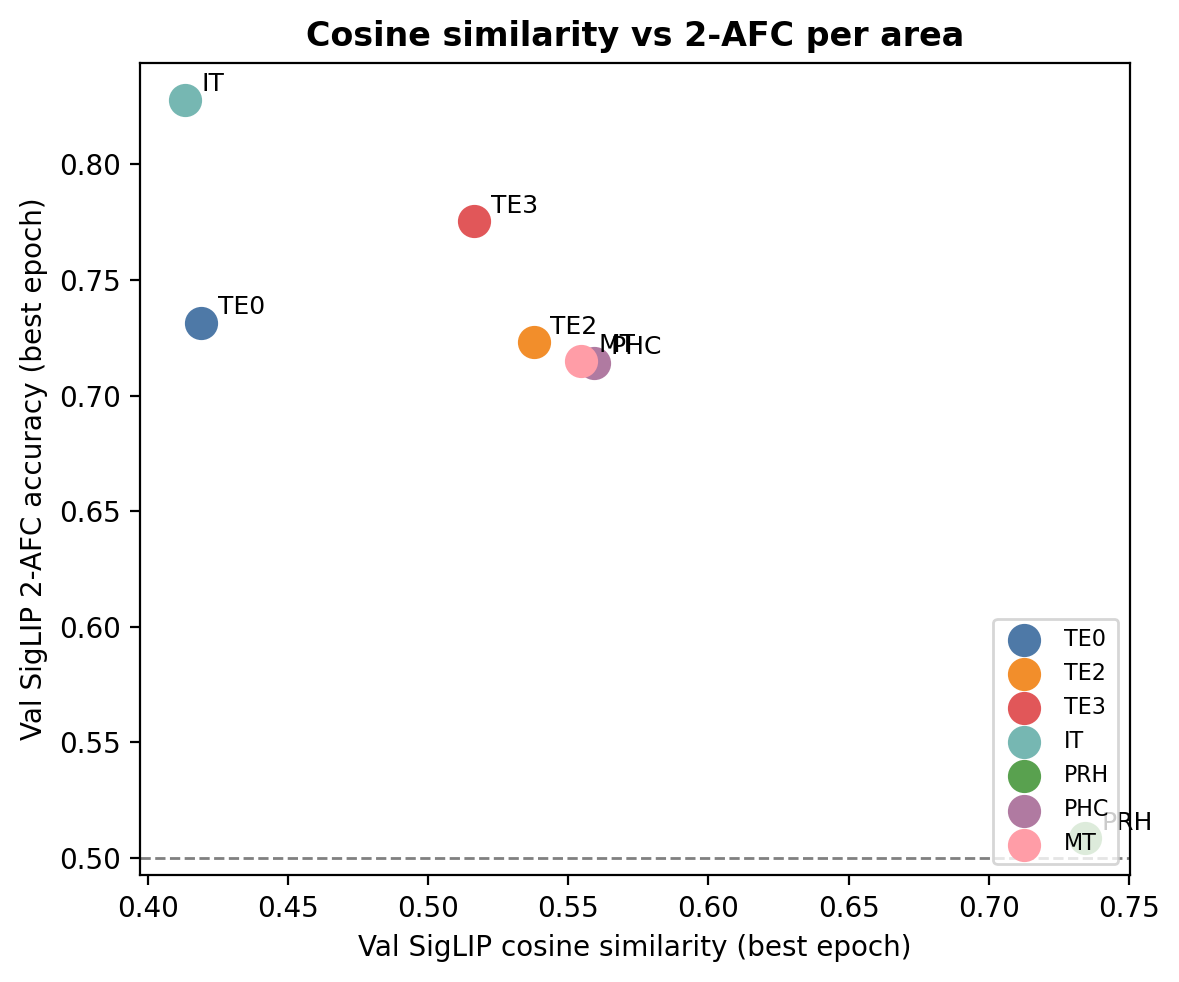

In [10]:
# Reload checkpoints for val curves (last.pt has the full training trace if logged,
# but we only saved scalars at best epoch — plot the best-epoch marker per area instead)
# For a training curve we need to reload all saved last.pt metrics; here we just
# show the per-area best val cos and 2afc as a scatter to reveal the cos/2afc relationship.

fig, ax = plt.subplots(figsize=(6, 5))
for a in areas_present:
    r = results[a]
    ax.scatter(r['val_cos'], r['val_2afc'], color=AREA_COLORS[a], s=120, zorder=3, label=a)
    ax.annotate(a, (r['val_cos'], r['val_2afc']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)

ax.axhline(0.5, color='grey', ls='--', lw=1)
ax.set_xlabel('Val SigLIP cosine similarity (best epoch)')
ax.set_ylabel('Val SigLIP 2-AFC accuracy (best epoch)')
ax.set_title('Cosine similarity vs 2-AFC per area', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
fig.tight_layout()
plt.show()
